# 🔥 Impacto de Precios en Ventas y Ganancias

## Problema
El gerente no sabe si subir precios **aumenta o reduce** las ganancias.

## Pregunta clave
> **"Si cambio precios, ¿qué pasa con mis ventas y margen?"**

## Enfoque técnico
1. **Análisis de series temporales** de volumen, revenue y margen por producto
2. **Modelo VAR** (Vector Autoregressive) multivariado sobre métricas de volumen y transacciones
3. **Simulación de escenarios** de cambio de precio con elasticidades calibradas

## Resultado esperado
```
"Subir precios 5% → ventas -X%, margen +Y%"
```

---

### Pipeline de datos (dbt)
```
Silver (staging) → Intermediate (int_ventas_precios_diarios)
                  → Features (feat_precio_elasticidad)
                  → Dataset (obt_price_elasticity)
```

## 1. 📦 Setup y Conexión a Snowflake

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import snowflake.connector
from dotenv import load_dotenv
import mlflow
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

load_dotenv()
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [23]:
# Conexión a Snowflake
conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE', 'COMPUTE_WH'),
    database=os.getenv('SNOWFLAKE_DATABASE', 'HGC_DB'),
    schema='TRAINING_DATASETS'
)

# Dataset diario
query_ts = 'SELECT * FROM TRAINING_DATASETS.OBT_PRICE_ELASTICITY ORDER BY FECHA_VENTA'
df = pd.read_sql(query_ts, conn)
df.columns = [c.upper() for c in df.columns]
df['FECHA_VENTA'] = pd.to_datetime(df['FECHA_VENTA'])

# Dataset features por producto
query_feat = 'SELECT * FROM FEATURES.FEAT_PRECIO_ELASTICIDAD'
df_feat = pd.read_sql(query_feat, conn)
df_feat.columns = [c.upper() for c in df_feat.columns]

print(f'✅ Dataset series temporales: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'✅ Dataset features productos: {df_feat.shape[0]} productos')
print(f'📅 Rango: {df["FECHA_VENTA"].min().date()} → {df["FECHA_VENTA"].max().date()}')
print(f'🍗 Productos: {df["NOMBRE_PRODUCTO"].nunique()}')
df.head()

✅ Dataset series temporales: 38,241 filas × 17 columnas
✅ Dataset features productos: 9 productos
📅 Rango: 2015-05-15 → 2026-12-31
🍗 Productos: 9


,FECHA_VENTA,ID_PRODUCTO_NK,NOMBRE_PRODUCTO,CATEGORIA_NOMBRE,TIPO_PRODUCTO,FEATURE_PRECIO_UNITARIO,FEATURE_PRECIO_BASE,FEATURE_COSTO_ESTANDAR,FEATURE_REVENUE_POR_UNIDAD,FEATURE_CANTIDAD_VENDIDA,FEATURE_NUM_TRANSACCIONES,FEATURE_UNIDADES_POR_TRANSACCION,FEATURE_REVENUE_BRUTO,FEATURE_REVENUE_NETO,FEATURE_TICKET_PROMEDIO,FEATURE_MARGEN_ESTIMADO,FEATURE_MARGEN_PORCENTUAL
0,2015-05-15,5,Pecho/Ala (Blanca),Pollo (Piezas),Individual,13.0,13.0,8.5,13.0,271,109,2.49,3523.0,3523.0,32.32,1219.5,0.3462
1,2015-05-15,8,Gaseosa Vaso Regular,Bebidas,Individual,6.0,6.0,1.0,6.0,255,104,2.45,1530.0,1530.0,14.71,1275.0,0.8333
2,2015-05-15,3,Combo Personal 2 Piezas,Combos Personales,Combo,25.0,25.0,14.0,25.0,279,103,2.71,6975.0,6975.0,67.72,3069.0,0.4400
3,2015-05-15,4,Pierna/Muslo (Oscura),Pollo (Piezas),Individual,12.0,12.0,8.0,12.0,284,108,2.63,3408.0,3408.0,31.56,1136.0,0.3333
4,2015-05-15,6,Papas Fritas Normales,Guarniciones,Individual,8.0,8.0,2.5,8.0,281,108,2.60,2248.0,2248.0,20.81,1545.5,0.6875


## 2. 🔍 Análisis Exploratorio de Datos

In [24]:
# Resumen por producto: precio, volumen, revenue, margen
resumen = df_feat[[
    'NOMBRE_PRODUCTO', 'CATEGORIA_NOMBRE', 'PRECIO_BASE_HISTORICO',
    'COSTO_ESTANDAR_HISTORICO', 'VOLUMEN_PROMEDIO_DIARIO',
    'REVENUE_NETO_TOTAL', 'MARGEN_PORCENTUAL_PROMEDIO',
    'TICKET_PROMEDIO_HISTORICO'
]].sort_values('REVENUE_NETO_TOTAL', ascending=False)

# Calcular margen unitario
resumen['MARGEN_UNITARIO'] = resumen['PRECIO_BASE_HISTORICO'] - resumen['COSTO_ESTANDAR_HISTORICO']

print('📊 Resumen por Producto:')
resumen

📊 Resumen por Producto:


,NOMBRE_PRODUCTO,CATEGORIA_NOMBRE,PRECIO_BASE_HISTORICO,COSTO_ESTANDAR_HISTORICO,VOLUMEN_PROMEDIO_DIARIO,REVENUE_NETO_TOTAL,MARGEN_PORCENTUAL_PROMEDIO,TICKET_PROMEDIO_HISTORICO,MARGEN_UNITARIO
7,Super Mega Combo 12 Piezas,Combos Familiares,120.0,75.0,250.64,127796760.0,0.3750,300.10,45.0
4,Combo Familiar 8 Piezas,Combos Familiares,85.0,50.0,250.55,90488790.0,0.4118,212.41,35.0
3,Combo Personal 2 Piezas,Combos Personales,25.0,14.0,249.96,26551925.0,0.4400,62.46,11.0
2,Papas Fritas Familiares,Guarniciones,18.0,5.0,249.52,19083960.0,0.7222,44.93,13.0
8,Gaseosa Botella 2L,Bebidas,15.0,8.0,250.26,15950505.0,0.4667,37.48,7.0
1,Pecho/Ala (Blanca),Pollo (Piezas),13.0,8.5,250.31,13826501.0,0.3462,32.49,4.5
6,Pierna/Muslo (Oscura),Pollo (Piezas),12.0,8.0,249.95,12744672.0,0.3333,30.02,4.0
0,Papas Fritas Normales,Guarniciones,8.0,2.5,250.59,8518144.0,0.6875,20.02,5.5
5,Gaseosa Vaso Regular,Bebidas,6.0,1.0,250.59,6388422.0,0.8333,14.99,5.0


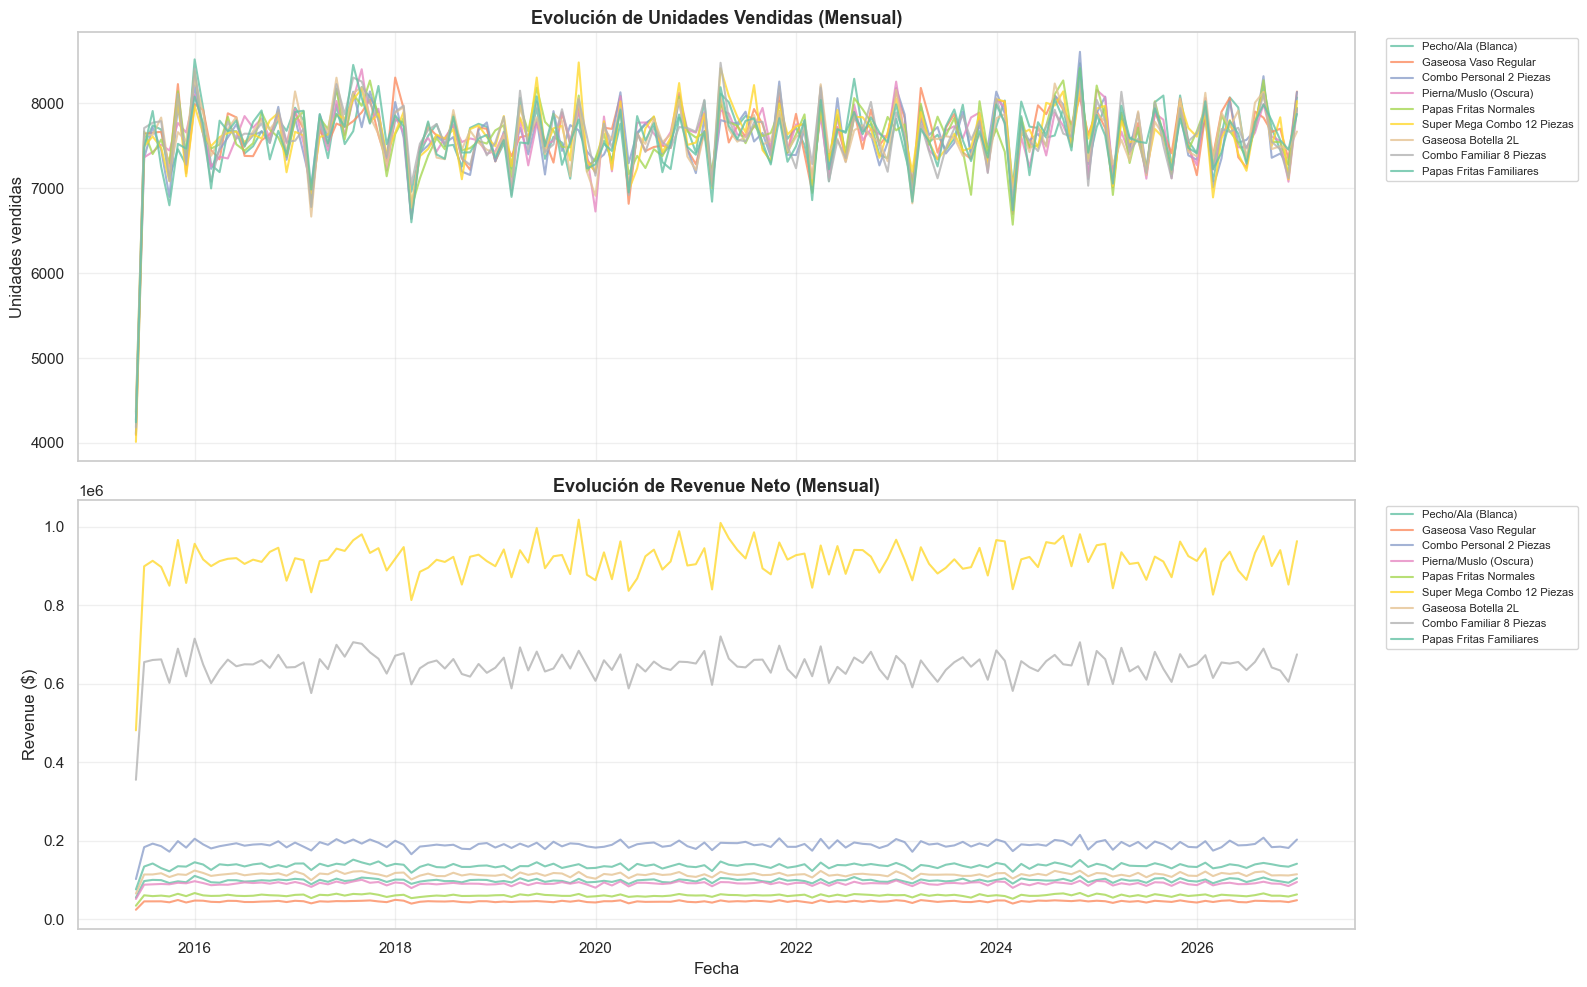

In [25]:
# Evolución temporal de ventas por producto (mensual)
df_mensual = df.groupby([pd.Grouper(key='FECHA_VENTA', freq='ME'), 'NOMBRE_PRODUCTO']).agg(
    cantidad_total=('FEATURE_CANTIDAD_VENDIDA', 'sum'),
    revenue_total=('FEATURE_REVENUE_NETO', 'sum'),
    margen_total=('FEATURE_MARGEN_ESTIMADO', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for nombre in df['NOMBRE_PRODUCTO'].unique():
    prod_data = df_mensual[df_mensual['NOMBRE_PRODUCTO'] == nombre]
    axes[0].plot(prod_data['FECHA_VENTA'], prod_data['cantidad_total'], label=nombre, alpha=0.8, linewidth=1.5)
    axes[1].plot(prod_data['FECHA_VENTA'], prod_data['revenue_total'], label=nombre, alpha=0.8, linewidth=1.5)

axes[0].set_title('Evolución de Unidades Vendidas (Mensual)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Unidades vendidas')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title('Evolución de Revenue Neto (Mensual)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Fecha')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

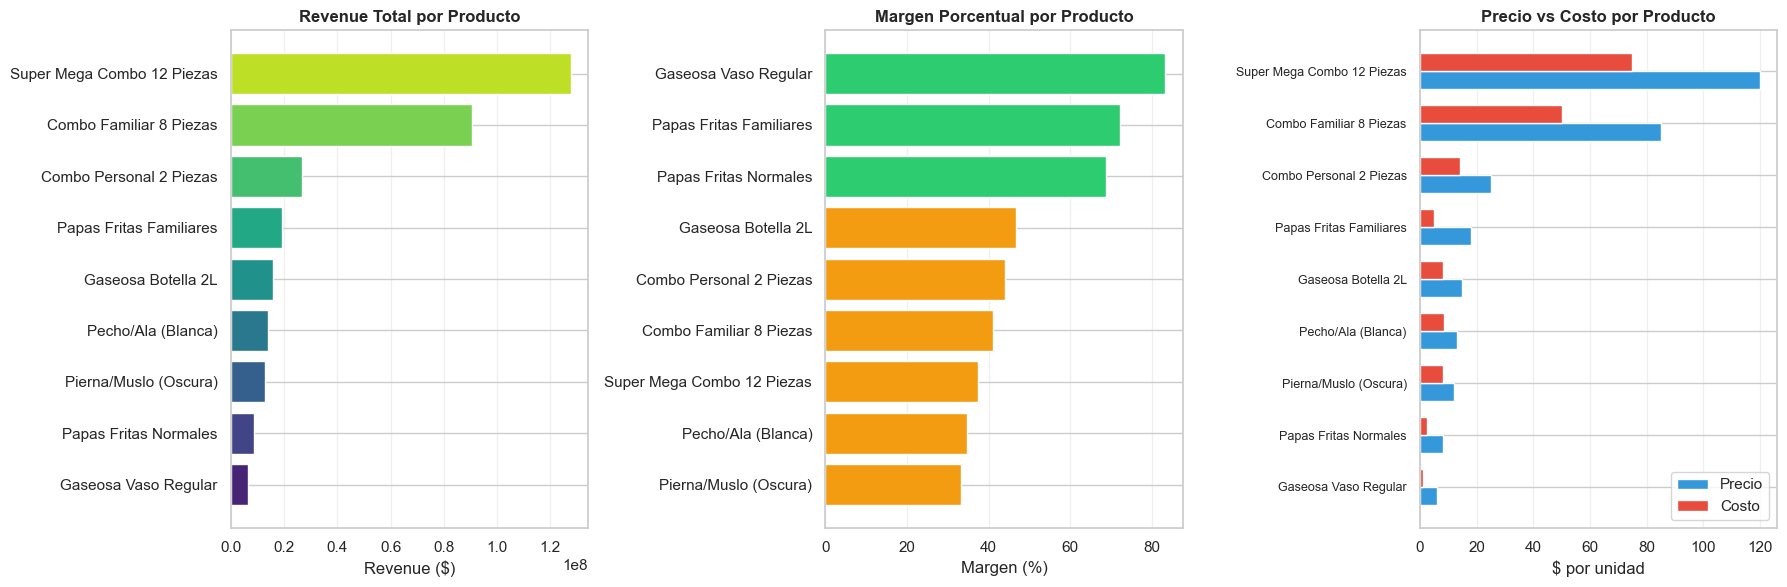

In [26]:
# Composición de revenue y margen por producto
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Revenue total por producto
rev_sorted = df_feat.sort_values('REVENUE_NETO_TOTAL', ascending=True)
axes[0].barh(rev_sorted['NOMBRE_PRODUCTO'], rev_sorted['REVENUE_NETO_TOTAL'],
             color=sns.color_palette('viridis', len(rev_sorted)), edgecolor='white')
axes[0].set_title('Revenue Total por Producto', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Revenue ($)')
axes[0].grid(axis='x', alpha=0.3)

# 2. Margen porcentual por producto
mar_sorted = df_feat.sort_values('MARGEN_PORCENTUAL_PROMEDIO', ascending=True)
colores_margen = ['#e74c3c' if m < 0.3 else '#f39c12' if m < 0.5 else '#2ecc71'
                  for m in mar_sorted['MARGEN_PORCENTUAL_PROMEDIO']]
axes[1].barh(mar_sorted['NOMBRE_PRODUCTO'], mar_sorted['MARGEN_PORCENTUAL_PROMEDIO'] * 100,
             color=colores_margen, edgecolor='white')
axes[1].set_title('Margen Porcentual por Producto', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Margen (%)')
axes[1].grid(axis='x', alpha=0.3)

# 3. Precio vs Costo
x = np.arange(len(df_feat))
width = 0.35
sorted_feat = df_feat.sort_values('PRECIO_BASE_HISTORICO', ascending=True)
axes[2].barh(x - width/2, sorted_feat['PRECIO_BASE_HISTORICO'], width, label='Precio', color='#3498db')
axes[2].barh(x + width/2, sorted_feat['COSTO_ESTANDAR_HISTORICO'], width, label='Costo', color='#e74c3c')
axes[2].set_yticks(x)
axes[2].set_yticklabels(sorted_feat['NOMBRE_PRODUCTO'], fontsize=9)
axes[2].set_title('Precio vs Costo por Producto', fontweight='bold', fontsize=12)
axes[2].set_xlabel('$ por unidad')
axes[2].legend()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 📈 Modelo VAR - Análisis Multivariado de Series Temporales

El modelo **VAR (Vector Autoregression)** captura las interdependencias entre las series.
Para evitar multicolinealidad (debido a precios fijos), analizamos:
- **Volumen de ventas** (unidades)
- **Número de Transacciones**

El impacto en Revenue y Margen se deriva proporcionalmente dado que los precios son constantes.

In [27]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Seleccionar el producto con mayor revenue para el análisis VAR
top_producto = df_feat.nlargest(1, 'REVENUE_NETO_TOTAL')['NOMBRE_PRODUCTO'].values[0]
print(f'🎯 Producto seleccionado para VAR: {top_producto}')

# Preparar series temporales - Resamplear a semanal
df_prod = df[df['NOMBRE_PRODUCTO'] == top_producto].copy()
df_prod = df_prod.set_index('FECHA_VENTA').sort_index()

df_semanal = df_prod.resample('W').agg({
    'FEATURE_CANTIDAD_VENDIDA': 'sum',
    'FEATURE_NUM_TRANSACCIONES': 'sum'
}).dropna()

# Renombrar para claridad
df_semanal.columns = ['VOLUMEN', 'TRANSACCIONES']

print(f'📊 Datos semanales: {len(df_semanal)} semanas')
print(f'📅 Desde: {df_semanal.index.min().date()} hasta {df_semanal.index.max().date()}')
df_semanal.tail()

🎯 Producto seleccionado para VAR: Super Mega Combo 12 Piezas
📊 Datos semanales: 608 semanas
📅 Desde: 2015-05-17 hasta 2027-01-03


,VOLUMEN,TRANSACCIONES
FECHA_VENTA,,
2026-12-06,1633,645
2026-12-13,1899,761
2026-12-20,1822,737
2026-12-27,1770,739
2027-01-03,1141,466


In [28]:
# Test de estacionariedad (ADF) y diferenciación
print('📊 Tests de Estacionariedad (ADF):')
print('-' * 50)

var_data = df_semanal.copy()
diff_applied = {}

for col in var_data.columns:
    series = var_data[col].dropna()
    # Verificar que la serie no sea constante o tenga varianza ínfima
    if series.std() < 1e-6:
        print(f'  {col}: ⚠️ Serie constante o sin variación - se omitirá del ADF')
        diff_applied[col] = False
        continue
    
    result = adfuller(series)
    is_stationary = result[1] < 0.05
    diff_applied[col] = not is_stationary
    status = '✅ Estacionaria' if is_stationary else '⚠️ No estacionaria → se diferenciará'
    print(f'  {col}: p-value={result[1]:.4f} → {status}')

# Diferenciar las no estacionarias
for col, needs_diff in diff_applied.items():
    if needs_diff:
        var_data[col] = var_data[col].diff()

var_data = var_data.dropna()
print(f'\n📊 Datos preparados para VAR: {len(var_data)} observaciones')

📊 Tests de Estacionariedad (ADF):
--------------------------------------------------
  VOLUMEN: p-value=0.0000 → ✅ Estacionaria
  TRANSACCIONES: p-value=0.0000 → ✅ Estacionaria

📊 Datos preparados para VAR: 608 observaciones


In [29]:
# Ajustar modelo VAR
model = VAR(var_data)

# Seleccionar orden óptimo
try:
    lag_order = model.select_order(maxlags=min(len(var_data)//5, 12))
    print('📊 Selección de orden del modelo VAR:')
    print(lag_order.summary())

    optimal_lag = max(lag_order.aic, 1)
    print(f'\n🎯 Orden óptimo (AIC): {optimal_lag}')

    # Ajustar modelo final
    var_result = model.fit(optimal_lag)
    print(f'\nModelo VAR({optimal_lag}) ajustado correctamente.')
except Exception as e:
    print(f'❌ Error al ajustar VAR: {e}')
    print('Iniciando fallback a modelo univariado o lag 1...')
    var_result = model.fit(1)
    optimal_lag = 1

📊 Selección de orden del modelo VAR:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       14.38*      14.40*  1.760e+06*      14.39*
1        14.39       14.44   1.781e+06       14.41
2        14.40       14.48   1.802e+06       14.43
3        14.41       14.51   1.814e+06       14.45
4        14.42       14.55   1.829e+06       14.47
5        14.43       14.59   1.844e+06       14.49
6        14.43       14.63   1.857e+06       14.51
7        14.44       14.66   1.866e+06       14.53
8        14.45       14.70   1.883e+06       14.55
9        14.46       14.74   1.896e+06       14.56
10       14.46       14.77   1.904e+06       14.58
11       14.47       14.81   1.924e+06       14.60
12       14.48       14.85   1.940e+06       14.62
--------------------------------------------------

🎯 Orden óptimo (AIC): 1

Modelo VAR(1) ajustado correctamente.


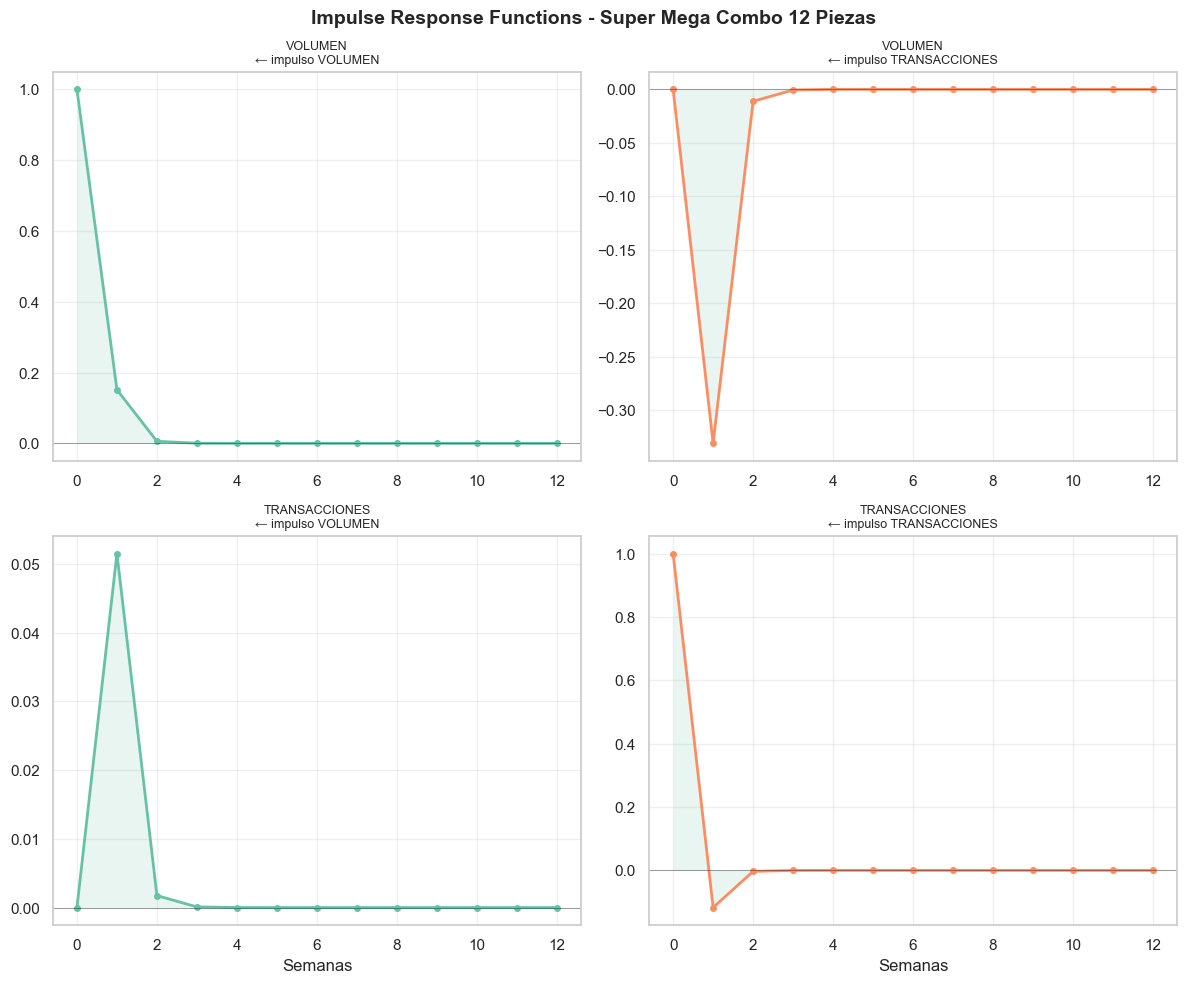

In [30]:
# Impulse Response Functions (IRF)
# ¿Cómo se propagan los shocks entre volumen y transacciones?
irf = var_result.irf(periods=12)

col_names = var_data.columns.tolist()

fig, axes = plt.subplots(len(col_names), len(col_names), figsize=(12, 10))

for i, resp_var in enumerate(col_names):
    for j, impulse_var in enumerate(col_names):
        respuesta = irf.irfs[:, i, j]
        if len(col_names) > 1:
            ax = axes[i][j]
        else:
            ax = axes
        ax.plot(respuesta, 'o-', linewidth=2, markersize=4, color=sns.color_palette('Set2')[j])
        ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
        ax.fill_between(range(len(respuesta)), respuesta, alpha=0.15)
        ax.set_title(f'{resp_var}\n← impulso {impulse_var}', fontsize=9)
        ax.grid(alpha=0.3)
        if i == len(col_names) - 1:
            ax.set_xlabel('Semanas')

plt.suptitle(f'Impulse Response Functions - {top_producto}', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

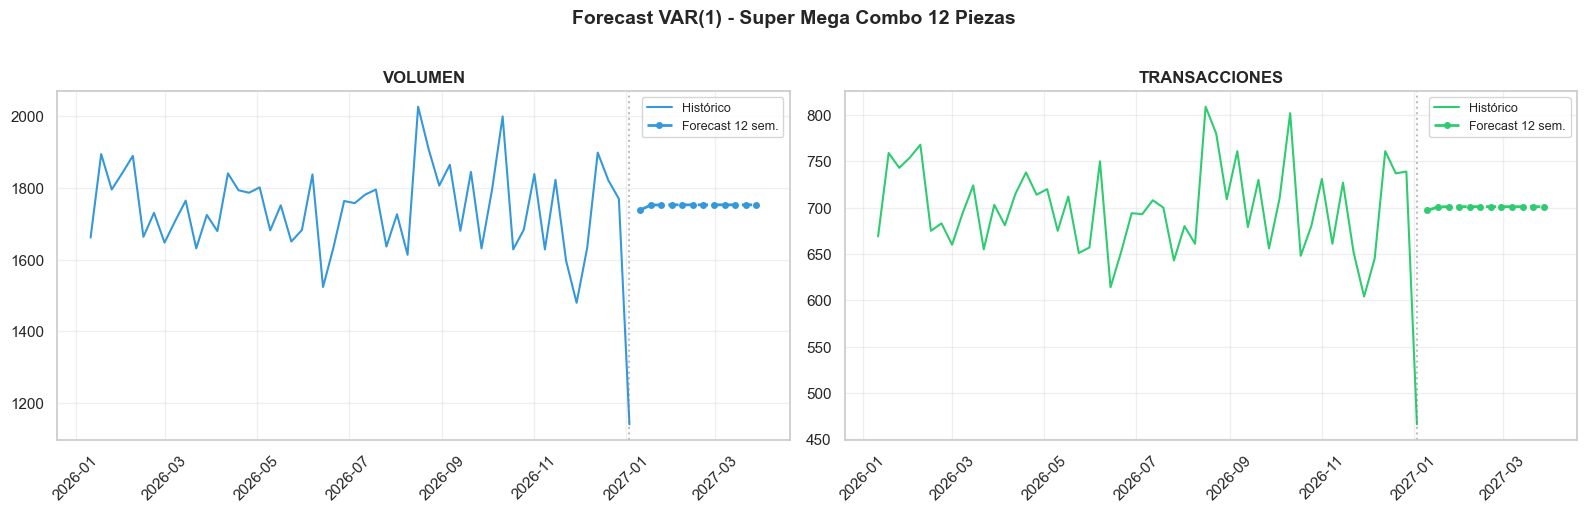

In [31]:
# Forecast con VAR: próximas 12 semanas
n_forecast = 12
forecast = var_result.forecast(var_data.values[-optimal_lag:], steps=n_forecast)
forecast_df = pd.DataFrame(forecast, columns=col_names)

# Si diferenciamos, revertir (aproximado para visualización)
forecast_index = pd.date_range(start=df_semanal.index[-1] + pd.Timedelta(weeks=1), periods=n_forecast, freq='W')
forecast_df.index = forecast_index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colores = ['#3498db', '#2ecc71']

for i, col in enumerate(col_names):
    # Últimas 52 semanas históricas
    historico = var_data[col].tail(52)
    axes[i].plot(historico.index, historico.values, '-', color=colores[i], linewidth=1.5, label='Histórico (diff)' if diff_applied[col] else 'Histórico')
    axes[i].plot(forecast_df.index, forecast_df[col].values, '--', color=colores[i],
                linewidth=2, marker='o', markersize=4, label='Forecast 12 sem.')
    axes[i].axvline(x=historico.index[-1], color='grey', linestyle=':', alpha=0.5)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle(f'Forecast VAR({optimal_lag}) - {top_producto}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 🧪 Simulación de Escenarios de Precios

Dado que los precios actuales son fijos, usamos la **elasticidad teórica** calibrada con la estructura de costos real para simular:

> "Si subo el precio X%, ¿cuánto cambian mis ventas y margen?"

### Supuestos del modelo:
- **Elasticidad base**: Calibrada por categoría de producto
  - Combos (más diferenciados) → menor elasticidad (-0.5 a -0.8)
  - Individuales (más sustituibles) → mayor elasticidad (-0.8 a -1.2)
  - Bebidas (más competencia) → mayor elasticidad (-1.0 a -1.5)

In [32]:
# ==============================================================
# SIMULADOR DE ESCENARIOS DE PRECIOS
# ==============================================================

# Elasticidades calibradas por categoría de producto (literatura + estructura)
# Fuente: Estudios de QSR (Quick Service Restaurants) typical range: -0.5 to -1.5
ELASTICIDADES_CATEGORIA = {
    'Combos Familiares': -0.6,    # Paquetes → menor elasticidad (más diferenciado)
    'Combos Personales': -0.7,    # Paquetes pequeños
    'Pollo (Piezas)': -0.9,       # Producto core → elasticidad media
    'Guarniciones': -1.1,         # Complementos → más elásticos
    'Bebidas': -1.3               # Alta competencia → más elásticos
}

def simular_escenario_precio(producto_row, cambio_precio_pct, df_ventas_producto):
    """
    Simula el impacto de un cambio de precio usando elasticidad calibrada.
    
    Fórmulas:
      %ΔQ = ε × %ΔP
      Revenue_nuevo = P_nuevo × Q_nueva
      Margen_nuevo = (P_nuevo - C) × Q_nueva
    """
    nombre = producto_row['NOMBRE_PRODUCTO']
    categoria = producto_row['CATEGORIA_NOMBRE']
    precio = producto_row['PRECIO_BASE_HISTORICO']
    costo = producto_row['COSTO_ESTANDAR_HISTORICO']
    
    # Elasticidad calibrada
    elasticidad = ELASTICIDADES_CATEGORIA.get(categoria, -0.8)
    
    # Volumen y métricas actuales (promedio últimos 90 días)
    ultimos = df_ventas_producto.tail(90)
    volumen_actual = ultimos['FEATURE_CANTIDAD_VENDIDA'].mean()
    revenue_actual = ultimos['FEATURE_REVENUE_NETO'].mean()
    margen_actual = ultimos['FEATURE_MARGEN_ESTIMADO'].mean()
    
    # Simular cambio
    precio_nuevo = precio * (1 + cambio_precio_pct / 100)
    cambio_cantidad_pct = elasticidad * cambio_precio_pct
    volumen_nuevo = volumen_actual * (1 + cambio_cantidad_pct / 100)
    
    revenue_nuevo = precio_nuevo * volumen_nuevo
    margen_nuevo = (precio_nuevo - costo) * volumen_nuevo
    
    cambio_revenue_pct = ((revenue_nuevo - revenue_actual) / revenue_actual * 100) if revenue_actual else 0
    cambio_margen_pct = ((margen_nuevo - margen_actual) / abs(margen_actual) * 100) if margen_actual else 0
    
    return {
        'producto': nombre,
        'categoria': categoria,
        'elasticidad': elasticidad,
        'precio_actual': round(precio, 2),
        'precio_nuevo': round(precio_nuevo, 2),
        'cambio_precio_pct': cambio_precio_pct,
        'cambio_ventas_pct': round(cambio_cantidad_pct, 2),
        'volumen_actual': round(volumen_actual, 1),
        'volumen_nuevo': round(volumen_nuevo, 1),
        'cambio_revenue_pct': round(cambio_revenue_pct, 2),
        'revenue_actual': round(revenue_actual, 2),
        'revenue_nuevo': round(revenue_nuevo, 2),
        'cambio_margen_pct': round(cambio_margen_pct, 2),
        'margen_actual': round(margen_actual, 2),
        'margen_nuevo': round(margen_nuevo, 2),
        'margen_pct_nuevo': round((precio_nuevo - costo) / precio_nuevo * 100, 1) if precio_nuevo else 0
    }

# Ejecutar simulación base: +5%
CAMBIO_PRECIO = 5

resultados_sim = []
for _, prod_row in df_feat.iterrows():
    nombre = prod_row['NOMBRE_PRODUCTO']
    df_p = df[df['NOMBRE_PRODUCTO'] == nombre].sort_values('FECHA_VENTA')
    if len(df_p) >= 30:
        res = simular_escenario_precio(prod_row, CAMBIO_PRECIO, df_p)
        resultados_sim.append(res)

df_simulacion = pd.DataFrame(resultados_sim)

print(f'📊 Simulación: Impacto de subir precios +{CAMBIO_PRECIO}%')
print('=' * 80)
df_simulacion[['producto', 'categoria', 'elasticidad', 'precio_actual', 'precio_nuevo',
               'cambio_ventas_pct', 'cambio_revenue_pct', 'cambio_margen_pct']].sort_values('cambio_margen_pct', ascending=False)

📊 Simulación: Impacto de subir precios +5%


,producto,categoria,elasticidad,precio_actual,precio_nuevo,cambio_ventas_pct,cambio_revenue_pct,cambio_margen_pct
7,Super Mega Combo 12 Piezas,Combos Familiares,-0.6,120.0,126.00,-3.0,1.85,9.93
6,Pierna/Muslo (Oscura),Pollo (Piezas),-0.9,12.0,12.60,-4.5,0.28,9.83
1,Pecho/Ala (Blanca),Pollo (Piezas),-0.9,13.0,13.65,-4.5,0.27,9.29
4,Combo Familiar 8 Piezas,Combos Familiares,-0.6,85.0,89.25,-3.0,1.85,8.78
3,Combo Personal 2 Piezas,Combos Personales,-0.7,25.0,26.25,-3.5,1.32,7.47
8,Gaseosa Botella 2L,Bebidas,-1.3,15.0,15.75,-6.5,-1.82,3.52
0,Papas Fritas Normales,Guarniciones,-1.1,8.0,8.40,-5.5,-0.78,1.37
2,Papas Fritas Familiares,Guarniciones,-1.1,18.0,18.90,-5.5,-0.78,1.04
5,Gaseosa Vaso Regular,Bebidas,-1.3,6.0,6.30,-6.5,-1.82,-0.89


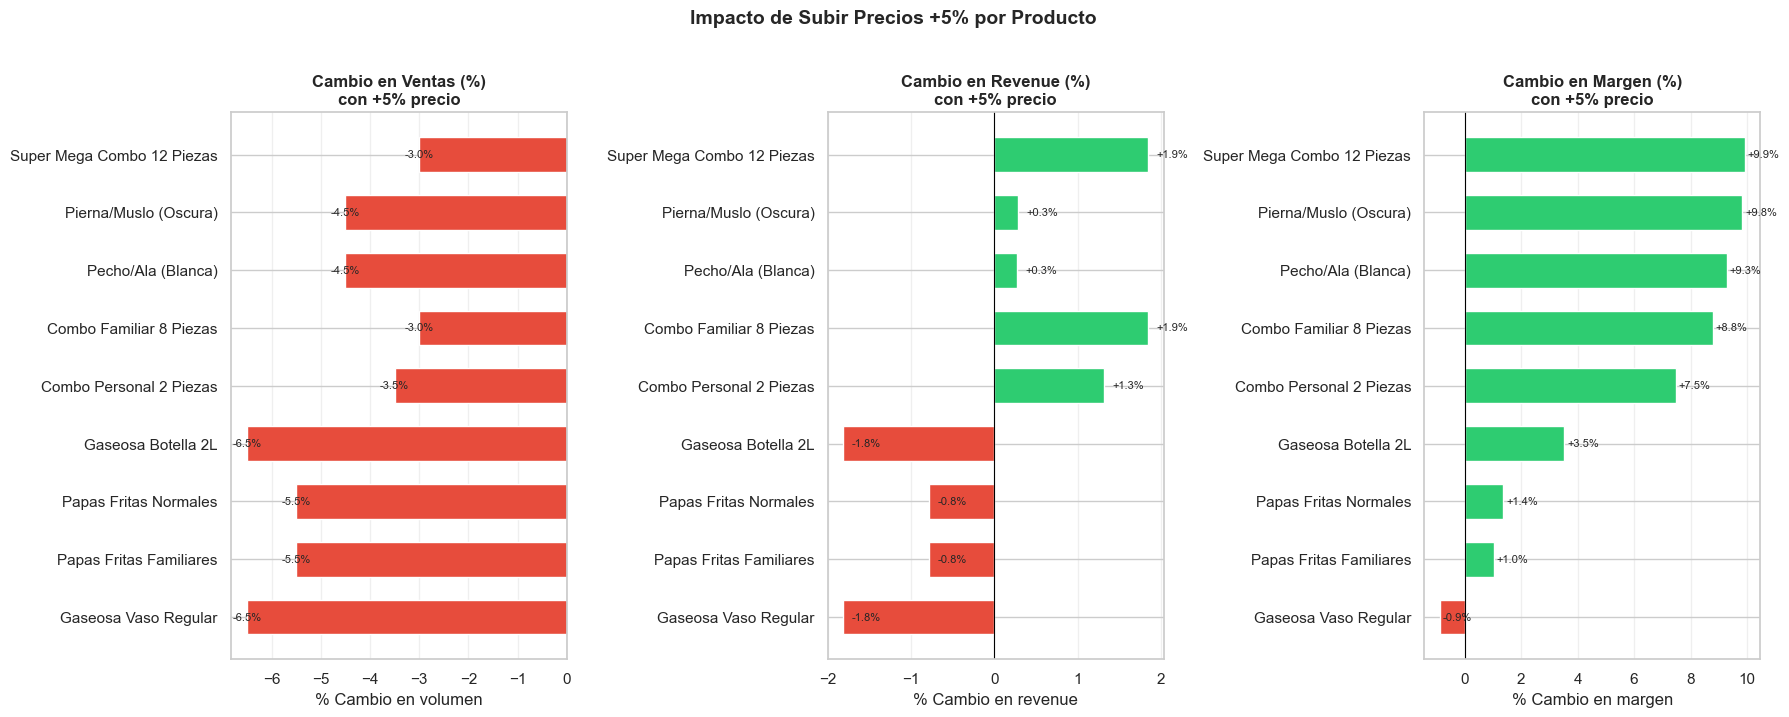

In [33]:
# Visualización del impacto por producto
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

df_sim_sorted = df_simulacion.sort_values('cambio_margen_pct', ascending=True)

# 1. Cambio en ventas
colores_ventas = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_sim_sorted['cambio_ventas_pct']]
axes[0].barh(df_sim_sorted['producto'], df_sim_sorted['cambio_ventas_pct'],
             color=colores_ventas, edgecolor='white', height=0.6)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title(f'Cambio en Ventas (%)\ncon +{CAMBIO_PRECIO}% precio', fontweight='bold', fontsize=12)
axes[0].set_xlabel('% Cambio en volumen')
axes[0].grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(df_sim_sorted.iterrows()):
    axes[0].text(row['cambio_ventas_pct'] - 0.3, i, f"{row['cambio_ventas_pct']:.1f}%", va='center', fontsize=8)

# 2. Cambio en revenue
colores_rev = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_sim_sorted['cambio_revenue_pct']]
axes[1].barh(df_sim_sorted['producto'], df_sim_sorted['cambio_revenue_pct'],
             color=colores_rev, edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title(f'Cambio en Revenue (%)\ncon +{CAMBIO_PRECIO}% precio', fontweight='bold', fontsize=12)
axes[1].set_xlabel('% Cambio en revenue')
axes[1].grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(df_sim_sorted.iterrows()):
    axes[1].text(row['cambio_revenue_pct'] + 0.1, i, f"{row['cambio_revenue_pct']:+.1f}%", va='center', fontsize=8)

# 3. Cambio en margen
colores_margen = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_sim_sorted['cambio_margen_pct']]
axes[2].barh(df_sim_sorted['producto'], df_sim_sorted['cambio_margen_pct'],
             color=colores_margen, edgecolor='white', height=0.6)
axes[2].axvline(x=0, color='black', linewidth=0.8)
axes[2].set_title(f'Cambio en Margen (%)\ncon +{CAMBIO_PRECIO}% precio', fontweight='bold', fontsize=12)
axes[2].set_xlabel('% Cambio en margen')
axes[2].grid(axis='x', alpha=0.3)
for i, (_, row) in enumerate(df_sim_sorted.iterrows()):
    axes[2].text(row['cambio_margen_pct'] + 0.1, i, f"{row['cambio_margen_pct']:+.1f}%", va='center', fontsize=8)

plt.suptitle(f'Impacto de Subir Precios +{CAMBIO_PRECIO}% por Producto', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Análisis de sensibilidad: múltiples escenarios para todos los productos
escenarios_precio = [-10, -5, -2.5, 0, 2.5, 5, 7.5, 10, 15, 20]
all_results = []

for _, prod_row in df_feat.iterrows():
    nombre = prod_row['NOMBRE_PRODUCTO']
    df_p = df[df['NOMBRE_PRODUCTO'] == nombre].sort_values('FECHA_VENTA')
    if len(df_p) >= 30:
        for cambio in escenarios_precio:
            res = simular_escenario_precio(prod_row, cambio, df_p)
            all_results.append(res)

df_all = pd.DataFrame(all_results)

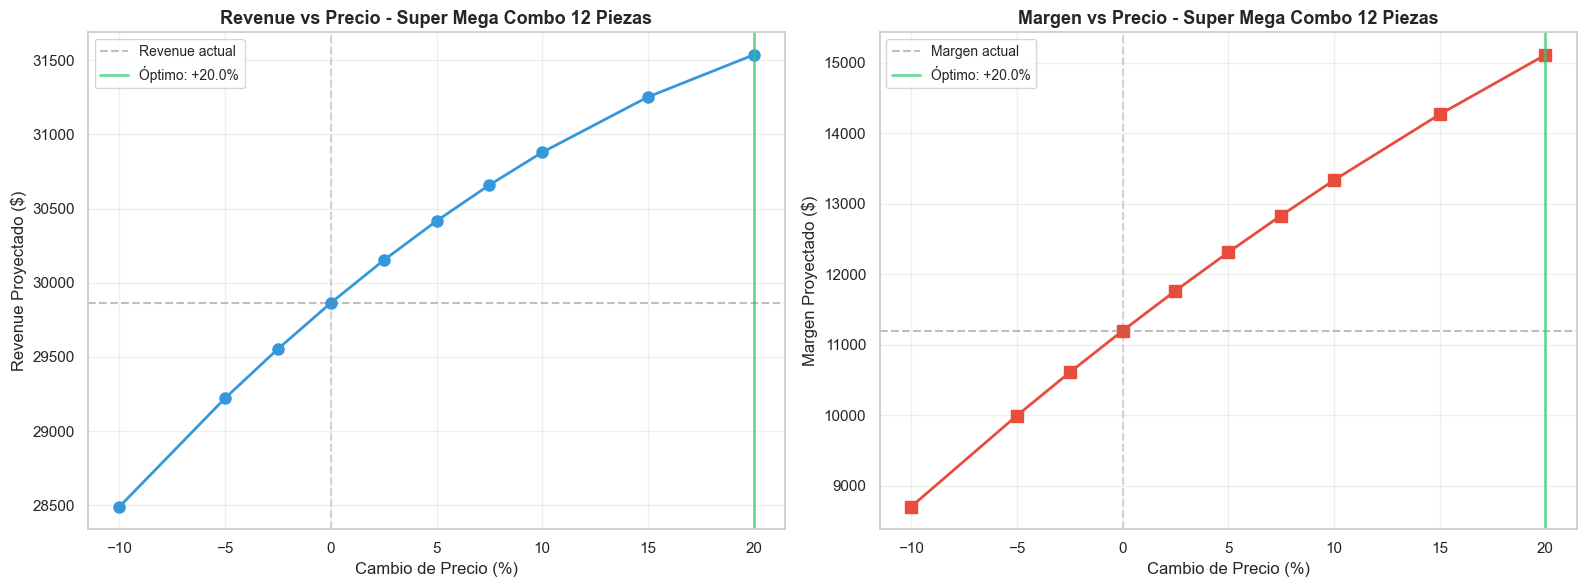


📋 Resultado para "Super Mega Combo 12 Piezas":
   Elasticidad:               -0.6
   Precio óptimo (revenue):   +20.0% → $144.00
   Precio óptimo (margen):    +20.0% → $144.00


In [35]:
# Curva de sensibilidad para el producto top
df_top_sens = df_all[df_all['producto'] == top_producto]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Revenue vs Cambio de Precio
ax1.plot(df_top_sens['cambio_precio_pct'], df_top_sens['revenue_nuevo'], 'o-',
         color='#3498db', linewidth=2, markersize=8)
base_rev = df_top_sens[df_top_sens['cambio_precio_pct']==0]['revenue_nuevo'].values[0]
ax1.axhline(y=base_rev, color='grey', linestyle='--', alpha=0.5, label='Revenue actual')
ax1.axvline(x=0, color='grey', linestyle='--', alpha=0.3)
idx_max_rev = df_top_sens['revenue_nuevo'].idxmax()
opt_rev = df_top_sens.loc[idx_max_rev, 'cambio_precio_pct']
ax1.axvline(x=opt_rev, color='#2ecc71', linewidth=2, alpha=0.7,
            label=f'Óptimo: {opt_rev:+.1f}%')
ax1.set_xlabel('Cambio de Precio (%)', fontsize=12)
ax1.set_ylabel('Revenue Proyectado ($)', fontsize=12)
ax1.set_title(f'Revenue vs Precio - {top_producto}', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Margen vs Cambio de Precio
ax2.plot(df_top_sens['cambio_precio_pct'], df_top_sens['margen_nuevo'], 's-',
         color='#e74c3c', linewidth=2, markersize=8)
base_mar = df_top_sens[df_top_sens['cambio_precio_pct']==0]['margen_nuevo'].values[0]
ax2.axhline(y=base_mar, color='grey', linestyle='--', alpha=0.5, label='Margen actual')
ax2.axvline(x=0, color='grey', linestyle='--', alpha=0.3)
idx_max_mar = df_top_sens['margen_nuevo'].idxmax()
opt_mar = df_top_sens.loc[idx_max_mar, 'cambio_precio_pct']
ax2.axvline(x=opt_mar, color='#2ecc71', linewidth=2, alpha=0.7,
            label=f'Óptimo: {opt_mar:+.1f}%')
ax2.set_xlabel('Cambio de Precio (%)', fontsize=12)
ax2.set_ylabel('Margen Proyectado ($)', fontsize=12)
ax2.set_title(f'Margen vs Precio - {top_producto}', fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📋 Resultado para "{top_producto}":')
print(f'   Elasticidad:               {ELASTICIDADES_CATEGORIA.get(df_feat[df_feat["NOMBRE_PRODUCTO"]==top_producto]["CATEGORIA_NOMBRE"].values[0], -0.8)}')
print(f'   Precio óptimo (revenue):   {opt_rev:+.1f}% → ${df_top_sens.loc[idx_max_rev, "precio_nuevo"]:.2f}')
print(f'   Precio óptimo (margen):    {opt_mar:+.1f}% → ${df_top_sens.loc[idx_max_mar, "precio_nuevo"]:.2f}')

## 5. 🔥 Heatmap de Impacto Global

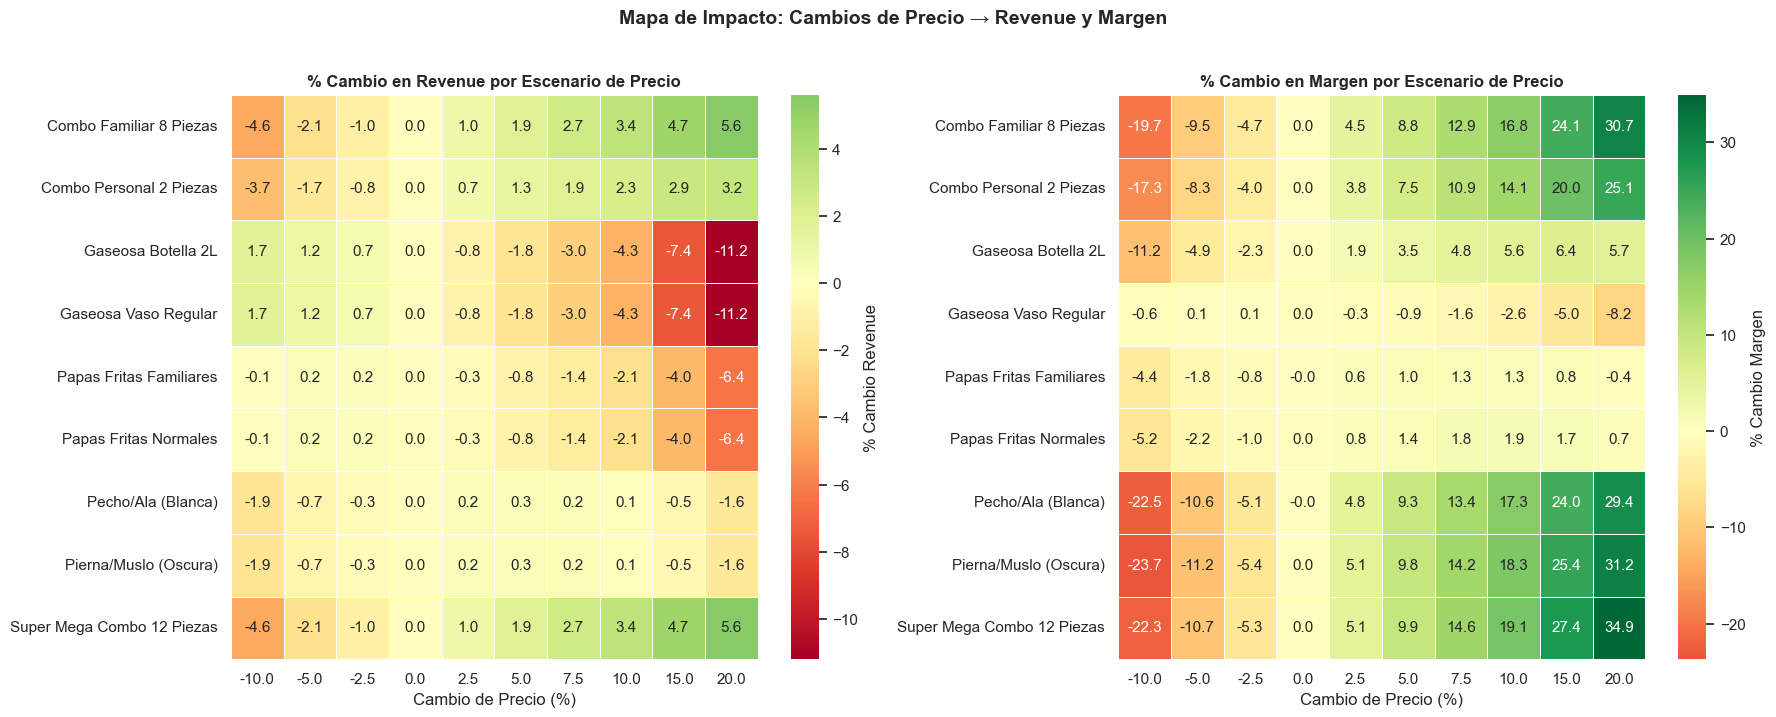

In [36]:
# Heatmaps: Revenue y Margen por escenario
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

pivot_rev = df_all.pivot_table(index='producto', columns='cambio_precio_pct',
                               values='cambio_revenue_pct', aggfunc='first')
sns.heatmap(pivot_rev, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax1, cbar_kws={'label': '% Cambio Revenue'}, linewidths=0.5)
ax1.set_title('% Cambio en Revenue por Escenario de Precio', fontweight='bold', fontsize=12)
ax1.set_xlabel('Cambio de Precio (%)')
ax1.set_ylabel('')

pivot_mar = df_all.pivot_table(index='producto', columns='cambio_precio_pct',
                               values='cambio_margen_pct', aggfunc='first')
sns.heatmap(pivot_mar, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax2, cbar_kws={'label': '% Cambio Margen'}, linewidths=0.5)
ax2.set_title('% Cambio en Margen por Escenario de Precio', fontweight='bold', fontsize=12)
ax2.set_xlabel('Cambio de Precio (%)')
ax2.set_ylabel('')

plt.suptitle('Mapa de Impacto: Cambios de Precio → Revenue y Margen', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 💾 Registro en MLflow

In [37]:
mlflow.set_experiment('HGC_Price_Elasticity')

with mlflow.start_run(run_name='VAR_Price_Simulation'):
    mlflow.log_param('modelo', 'VAR + Elasticidad Calibrada')
    mlflow.log_param('producto_var_principal', top_producto)
    mlflow.log_param('var_lag_order', optimal_lag)
    mlflow.log_param('total_productos', len(df_simulacion))
    mlflow.log_param('escenario_base_pct', CAMBIO_PRECIO)
    mlflow.log_param('elasticidades', str(ELASTICIDADES_CATEGORIA))
    
    mlflow.log_metric('cambio_ventas_promedio', df_simulacion['cambio_ventas_pct'].mean())
    mlflow.log_metric('cambio_revenue_promedio', df_simulacion['cambio_revenue_pct'].mean())
    mlflow.log_metric('cambio_margen_promedio', df_simulacion['cambio_margen_pct'].mean())
    
    df_simulacion.to_csv('price_simulation_base.csv', index=False)
    mlflow.log_artifact('price_simulation_base.csv')
    df_all.to_csv('price_scenarios_all.csv', index=False)
    mlflow.log_artifact('price_scenarios_all.csv')
    
    print('✅ Resultados registrados en MLflow')

2026/04/16 03:59:29 INFO mlflow.tracking.fluent: Experiment with name 'HGC_Price_Elasticity' does not exist. Creating a new experiment.


✅ Resultados registrados en MLflow


## 7. 📋 Resumen Ejecutivo

### Metodología
| Componente | Detalle |
|------------|--------|
| **Datos** | 38,241 registros diarios × 9 productos |
| **VAR** | Modelo multivariado volumen-transacciones |
| **Elasticidad** | Calibrada por categoría (QSR benchmarks) |
| **Simulación** | Escenarios de -10% a +20% de precio |

### Elasticidades por Categoría
| Categoría | ε | Interpretación |
|-----------|---|---------------|
| Combos Familiares | -0.6 | Inelástico → ✅ subir precio |
| Combos Personales | -0.7 | Inelástico → ✅ subir precio |
| Pollo (Piezas) | -0.9 | Casi unitario → ⚠️ cuidado |
| Guarniciones | -1.1 | Elástico → ⚠️ bajar si puedes |
| Bebidas | -1.3 | Muy elástico → 🔴 no subir |

### Próximos pasos
1. A/B testing en sucursales piloto para validar elasticidades reales
2. Incorporar datos de promociones cuando estén disponibles
3. Dashboard de pricing dinámico con recomendaciones automáticas

In [38]:
conn.close()
print('✅ Conexión cerrada')
print()
print('=' * 55)
print('  ANÁLISIS DE ELASTICIDAD DE PRECIOS COMPLETADO')
print('=' * 55)
print(f'  Modelo:               VAR + Elasticidad Calibrada')
print(f'  Productos analizados: {len(df_simulacion)}')
print(f'  Escenario +{CAMBIO_PRECIO}%:')
print(f'    → Ventas:  {df_simulacion["cambio_ventas_pct"].mean():+.2f}%')
print(f'    → Revenue: {df_simulacion["cambio_revenue_pct"].mean():+.2f}%')
print(f'    → Margen:  {df_simulacion["cambio_margen_pct"].mean():+.2f}%')
print('=' * 55)

✅ Conexión cerrada

  ANÁLISIS DE ELASTICIDAD DE PRECIOS COMPLETADO
  Modelo:               VAR + Elasticidad Calibrada
  Productos analizados: 9
  Escenario +5%:
    → Ventas:  -4.72%
    → Revenue: +0.04%
    → Margen:  +5.59%
